# Урок 3. Вероятности: softmax, температура, энтропия, перплексия

🎯 **Цели урока**

- написать устойчивый softmax и понять, почему наивный ломается;
- увидеть, как температура меняет распределение и его энтропию;
- получить **настоящее** распределение следующего токена от модели и сэмплировать из него
  с температурой, top-k и top-p;
- сравнить две модели через KL-дивергенцию;
- посчитать перплексию текста по вероятностям токенов.

📖 **Теория:** разделы «Вероятность» и «Теория информации».

⏱ Запросы к моделям записаны в кассеты `./cassettes`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mlcourse
from mlcourse import get_client, model_name, no_thinking

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)
print(mlcourse.describe_settings())

main   qwen3.8-27b  https://<удалённый сервер>/v1
local  qwen3:8b     http://localhost:11434/v1
embed  bge-m3       http://localhost:11434/v1
кэш    record       LLM_CACHE


## 1. Softmax: наивный и устойчивый

In [2]:
def softmax_naive(z):
    e = np.exp(z)
    return e / e.sum()


def softmax(z, temperature: float = 1.0):
    z = np.asarray(z, dtype=float) / temperature
    e = np.exp(z - z.max())  # сдвиг не меняет результат, но спасает от переполнения
    return e / e.sum()


z = np.array([1000.0, 1001.0, 1002.0])
with np.errstate(over="ignore", invalid="ignore"):
    print("наивный:   ", softmax_naive(z))
print("устойчивый:", softmax(z))
print("сдвиг на −1000 даёт то же самое:", softmax(z - 1000))

наивный:    [nan nan nan]
устойчивый: [0.09   0.2447 0.6652]
сдвиг на −1000 даёт то же самое: [0.09   0.2447 0.6652]


Наивная версия считает $e^{1000} = \infty$ и делит бесконечность на бесконечность.
В float16, где работают многие LLM, переполнение наступает гораздо раньше:

In [3]:
with np.errstate(over="ignore"):
    for x in [10, 11, 12]:
        print(f"exp({x}) в float16 = {np.exp(np.float16(x))}")

exp(10) в float16 = 22032.0
exp(11) в float16 = 59872.0
exp(12) в float16 = inf


## 2. Температура и энтропия

Энтропия $H(p) = -\sum p_i \log p_i$ измеряет «неуверенность» распределения.
Проследим, как она меняется с температурой.

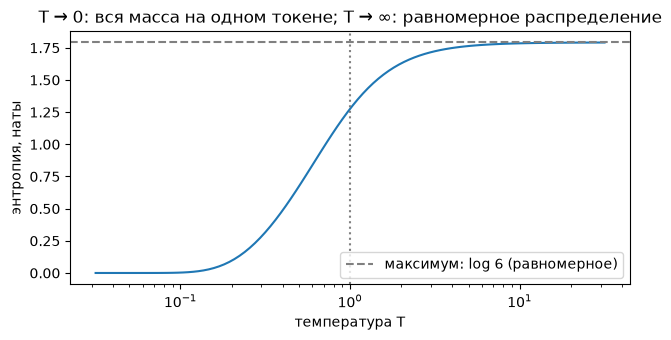

In [4]:
def entropy(p):
    p = np.asarray(p)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


logits = np.array([3.0, 2.2, 1.5, 0.8, 0.2, -0.5])
temps = np.logspace(-1.5, 1.5, 100)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.semilogx(temps, [entropy(softmax(logits, t)) for t in temps])
ax.axhline(np.log(len(logits)), ls="--", color="gray", label="максимум: log 6 (равномерное)")
ax.axvline(1, ls=":", color="gray")
ax.set_xlabel("температура T")
ax.set_ylabel("энтропия, наты")
ax.legend()
ax.set_title("T → 0: вся масса на одном токене; T → ∞: равномерное распределение")
plt.tight_layout()
plt.show()

## 3. Настоящее распределение следующего токена

OpenAI-совместимый API умеет возвращать логарифмы вероятностей (`logprobs`) сгенерированных
токенов и `top_logprobs` самых вероятных альтернатив. Попросим один токен и 20 альтернатив.
Параметр `temperature` на `logprobs` не влияет: сервер возвращает «сырое» распределение модели.

In [5]:
def next_token(prompt: str, role: str = "main", k: int = 20) -> tuple[list[str], np.ndarray]:
    """Топ-k токенов, которыми модель может начать ответ, и их log-вероятности."""
    r = get_client(role).chat.completions.create(
        model=model_name(role),
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1,
        logprobs=True,
        top_logprobs=k,
        temperature=0,
        extra_body=no_thinking(),
    )
    top = r.choices[0].logprobs.content[0].top_logprobs
    return [t.token for t in top], np.array([t.logprob for t in top])


animal = "Pick a random animal. Answer with a single word."
tokens, logp = next_token(animal)
p = np.exp(logp)
print(f"20 токенов покрывают {p.sum():.1%} вероятности\n")
for tok, prob in zip(tokens[:10], p[:10]):
    print(f"{tok!r:10} {prob:6.3f} {'█' * int(prob * 60)}")

20 токенов покрывают 97.1% вероятности

'O'         0.455 ███████████████████████████
'Ot'        0.170 ██████████
'Fox'       0.075 ████
'Oct'       0.063 ███
'Ele'       0.043 ██
'K'         0.029 █
'P'         0.025 █
'Ko'        0.021 █
'F'         0.014 
'D'         0.014 


Модель выбирает **токены**, а не слова: `'O'` и `'Ot'` — начала слов (Octopus, Otter).
Слово целиком складывается из нескольких шагов генерации.

### Температура поверх настоящих вероятностей

`logprob` — это $\log p_i = z_i - \operatorname{LSE}(z)$: логит минус константа. Softmax не замечает
сдвига на константу, поэтому применить температуру к `logprobs` — то же самое, что к логитам.
Правда, у нас только топ-20, и хвост распределения мы теряем.

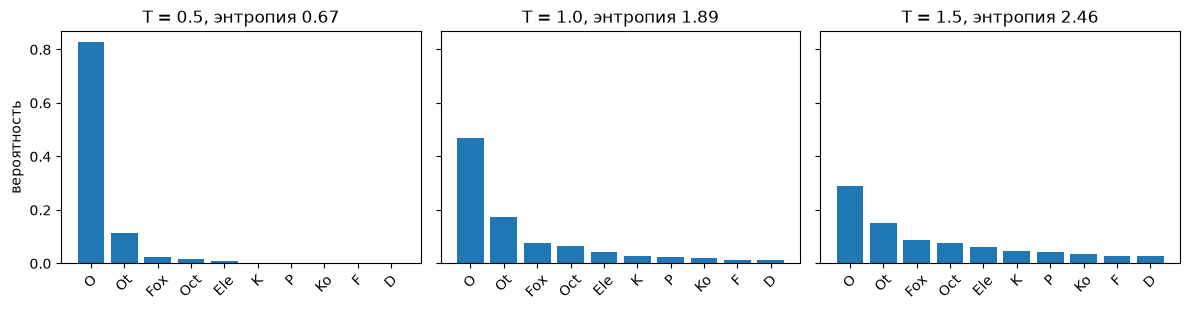

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 1.5]):
    pt = softmax(logp, t)
    ax.bar(range(10), pt[:10])
    ax.set_xticks(range(10), tokens[:10], rotation=45)
    ax.set_title(f"T = {t}, энтропия {entropy(pt):.2f}")
axes[0].set_ylabel("вероятность")
plt.tight_layout()
plt.show()

### Сэмплирование, top-k и top-p

In [7]:
def top_k_filter(probs, k):
    keep = np.zeros_like(probs)
    idx = np.argsort(-probs)[:k]
    keep[idx] = probs[idx]
    return keep / keep.sum()


def top_p_filter(probs, top_p):
    order = np.argsort(-probs)
    cumulative = np.cumsum(probs[order])
    n_keep = int(np.searchsorted(cumulative, top_p) + 1)  # наименьший набор с суммой ≥ top_p
    keep = np.zeros_like(probs)
    keep[order[:n_keep]] = probs[order[:n_keep]]
    return keep / keep.sum()


base = softmax(logp)
for name, dist in [("без фильтра", base), ("top-k = 3", top_k_filter(base, 3)),
                   ("top-p = 0.9", top_p_filter(base, 0.9))]:
    draws = rng.choice(len(tokens), size=1000, p=dist)
    counts = np.bincount(draws, minlength=len(tokens))
    alive = [tokens[i] for i in np.flatnonzero(dist)]
    print(f"{name:12} остаётся {len(alive):2} токенов; частоты на 1000 выборок:",
          {tokens[i]: int(counts[i]) for i in np.argsort(-counts)[:5] if counts[i]})

без фильтра  остаётся 20 токенов; частоты на 1000 выборок: {'O': 438, 'Ot': 182, 'Fox': 84, 'Oct': 70, 'Ele': 52}
top-k = 3    остаётся  3 токенов; частоты на 1000 выборок: {'O': 664, 'Ot': 228, 'Fox': 108}
top-p = 0.9  остаётся  8 токенов; частоты на 1000 выборок: {'O': 531, 'Ot': 188, 'Oct': 77, 'Fox': 76, 'Ele': 50}


Частоты на 1000 выборок близки к вероятностям. Фильтры отрезают «хвост» — редкие и часто
бессмысленные варианты, — после чего вероятности нормируются заново.

### Модели плохо умеют в случайность

Попросим «случайный» фрукт.

In [8]:
fruit = "Name one random fruit. Answer with a single word."
for role in ["main", "local"]:
    toks, lp = next_token(fruit, role)
    pr = np.exp(lp)
    print(f"{role:5} ({model_name(role)}):", ", ".join(f"{t!r} {q:.2f}" for t, q in zip(toks[:5], pr[:5])))

main  (qwen3.8-27b): 'M' 0.89, 'Apple' 0.06, 'Ki' 0.03, 'Ban' 0.01, 'P' 0.01
local (qwen3:8b): 'P' 0.53, 'M' 0.25, 'Apple' 0.10, 'Ban' 0.05, 'Ki' 0.03


«Случайный» выбор у модели сильно перекошен: один-два варианта забирают почти всю вероятность.
Если нужна настоящая случайность — например, для генерации разнообразных тестовых данных
в M22, — выбирайте варианты сами, кодом, и передавайте модели в промпт. Повышение температуры
лишь частично выравнивает распределение.

### Русский текст и токены

Посмотрим на русский вопрос.

In [9]:
toks, lp = next_token("Какого цвета небо в ясный день? Ответь одним словом.")
print(", ".join(f"{t!r} {q:.3f}" for t, q in zip(toks[:6], np.exp(lp[:6]))))

'С' 0.774, 'Г' 0.224, 'го' 0.001, 'Не' 0.000, 'син' 0.000, ' Син' 0.000


Первый токен ответа — одна буква: «С…» (синее) или «Г…» (голубое). Токенизатор режет русский
текст мельче английского, поэтому русский ответ стоит больше токенов, времени и денег.
Подробно — в M06.

## 4. Энтропия: насколько модель уверена

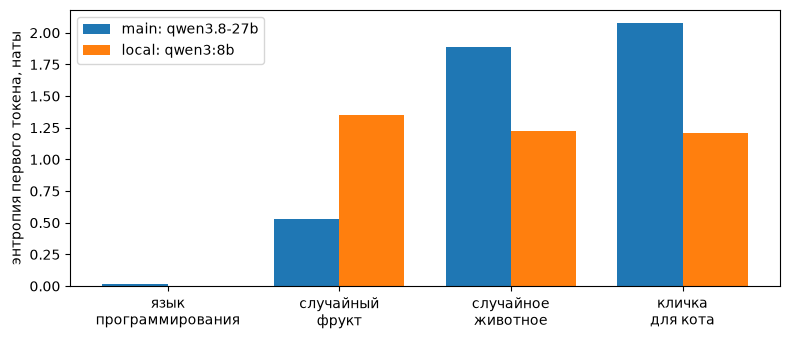

In [10]:
prompts = {
    "язык программирования": "Name a programming language. Answer with a single word.",
    "случайный фрукт": fruit,
    "случайное животное": animal,
    "кличка для кота": "Suggest a name for a ginger cat. Answer with a single word.",
}
H = {role: [entropy(softmax(next_token(q, role)[1])) for q in prompts.values()] for role in ["main", "local"]}

x = np.arange(len(prompts))
fig, ax = plt.subplots(figsize=(8, 3.5))
for i, role in enumerate(H):
    ax.bar(x + (i - 0.5) * 0.38, H[role], width=0.38, label=f"{role}: {model_name(role)}")
ax.set_xticks(x, [name.replace(" ", "\n", 1) for name in prompts])
ax.set_ylabel("энтропия первого токена, наты")
ax.legend()
plt.tight_layout()
plt.show()

На «язык программирования» обе модели уверены (Python почти со 100%). На творческих вопросах
энтропия выше, но у разных моделей по-разному. Энтропия следующего токена — полезный сигнал
в продакшне: высокая энтропия на фактическом вопросе — повод насторожиться (M22).

## 5. KL-дивергенция между моделями

Сравним распределения первого токена у двух моделей на одном вопросе. Токены, которых нет
в топ-20 одной из моделей, получают маленькую вероятность $10^{-6}$ — иначе KL бесконечна.

In [11]:
def aligned(prompt: str) -> tuple[list[str], np.ndarray, np.ndarray]:
    t1, l1 = next_token(prompt, "main")
    t2, l2 = next_token(prompt, "local")
    vocab = sorted(set(t1) | set(t2))
    p = np.array([np.exp(l1[t1.index(t)]) if t in t1 else 1e-6 for t in vocab])
    q = np.array([np.exp(l2[t2.index(t)]) if t in t2 else 1e-6 for t in vocab])
    return vocab, p / p.sum(), q / q.sum()


def kl(p, q):
    return float(np.sum(p * np.log(p / q)))


for name in ["случайный фрукт", "случайное животное", "язык программирования"]:
    vocab, p_main, p_local = aligned(prompts[name])
    print(f"{name:22} KL(main‖local) = {kl(p_main, p_local):6.2f}   KL(local‖main) = {kl(p_local, p_main):6.2f}")

случайный фрукт        KL(main‖local) =   1.10   KL(local‖main) =   2.39


случайное животное     KL(main‖local) =  10.33   KL(local‖main) =   4.28
язык программирования  KL(main‖local) =   0.02   KL(local‖main) =   0.00


KL несимметрична: $\mathrm{KL}(p\,\|\,q)$ сильно штрафует случаи, когда $p$ уверена в токене,
а $q$ считает его почти невозможным. Где модели согласны (Python), KL близка к нулю.
Этот же инструмент используют при **дистилляции** (ученик приближает распределение учителя)
и в **RLHF** (штраф за уход от исходной модели).

## 6. Перплексия текста

Попросим модель сгенерировать текст и вернуть `logprobs` каждого сгенерированного токена.
Средний $-\log p$ — кросс-энтропия на токен, её экспонента — перплексия.

In [12]:
def generate(prompt: str, temperature: float, max_tokens: int = 60, role: str = "main"):
    r = get_client(role).chat.completions.create(
        model=model_name(role),
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=temperature,
        seed=1,
        logprobs=True,
        extra_body=no_thinking(),
    )
    content = r.choices[0].logprobs.content
    return r.choices[0].message.content, [t.token for t in content], np.array([t.logprob for t in content])


cases = {
    "факты, T=0": ("Объясни в двух предложениях, что такое градиентный спуск.", 0.0),
    "сказка, T=0.7": ("Сочини начало сказки про робота-садовника, два предложения.", 0.7),
    "сказка, T=1.5": ("Сочини начало сказки про робота-садовника, два предложения.", 1.5),
}
results = {}
for name, (prompt, t) in cases.items():
    text, toks, lp = generate(prompt, t)
    nll = -lp.mean()
    results[name] = (toks, lp)
    print(f"── {name}: {len(toks)} токенов, NLL = {nll:.3f} ната = {nll / np.log(2):.2f} бита, PPL = {np.exp(nll):.2f}")
    print(text, "\n")

── факты, T=0: 60 токенов, NLL = 0.166 ната = 0.24 бита, PPL = 1.18
Градиентный спуск — это итеративный алгоритм оптимизации, который находит минимум функции, последовательно перемещаясь в направлении, противоположном вектору градиента (наибольшего роста). Этот процесс продолжается до тех пор, пока не 

── сказка, T=0.7: 60 токенов, NLL = 0.684 ната = 0.99 бита, PPL = 1.98
Жили-были в старом особняке с башенкой неуклюжий, но добрый робот-садовник и его верный помощник — маленькая сова по имени Пыль. Каждое утро, когда первые лучи солнца касались острых ш 

── сказка, T=1.5: 60 токенов, NLL = 1.440 ната = 2.08 бита, PPL = 4.22
У старого заброда, где время замерло среди вьющихся роз, проживал маленький робот, который вместо гвоздотёрки держал в железных ладонях нежный черенок. Каждое утро он неспешно поливал землю, уверенный, что из каждого 



Перплексия собственного ответа модели при $T = 0$ близка к 1: модель каждый раз брала
самый вероятный токен. Чем выше температура, тем чаще выбираются маловероятные токены
и тем выше перплексия. При $T = 1{,}5$ в тексте появились несуществующие слова: маловероятные
токены склеились в «слова», которых нет в языке. Посмотрим, какие токены «удивили» модель
сильнее всего в тексте с $T = 0{,}7$.

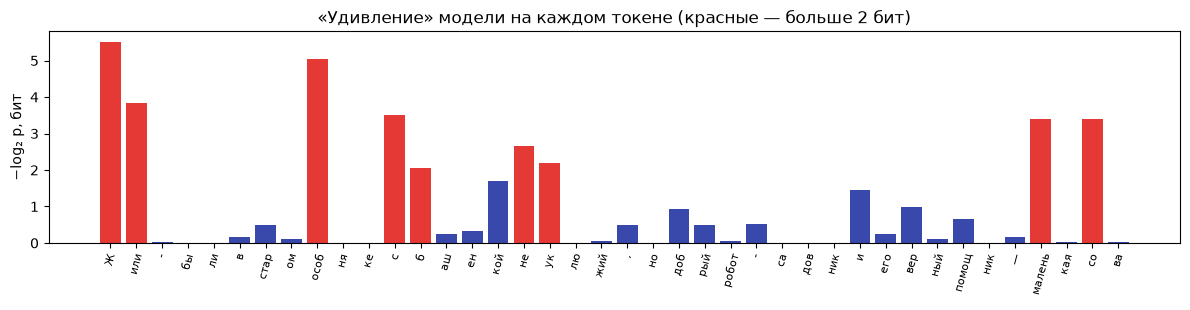

In [13]:
toks, lp = results["сказка, T=0.7"]
surprise = -lp / np.log(2)  # в битах
n = min(40, len(toks))
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.bar(range(n), surprise[:n], color=["#E53935" if s > 2 else "#3949AB" for s in surprise[:n]])
ax.set_xticks(range(n), [t.replace("\n", "⏎") for t in toks[:n]], rotation=75, fontsize=8)
ax.set_ylabel("−log₂ p, бит")
ax.set_title("«Удивление» модели на каждом токене (красные — больше 2 бит)")
plt.tight_layout()
plt.show()

Большая часть токенов почти ничего не стоит: окончания слов и служебные слова однозначны
по контексту. «Дорогие» токены — места, где модель делала выбор: начало нового образа,
неожиданное слово. Именно в таких местах температура меняет текст.

## ✅ Итоги

- Softmax считают со сдвигом на максимум, логарифмы — через `logsumexp`.
- Температура делит логиты: низкая делает распределение острым, высокая — плоским.
  Применять её к `logprobs` можно, потому что softmax инвариантен к сдвигу.
- Top-k и top-p отрезают хвост распределения перед сэмплированием.
- Энтропия показывает уверенность модели, KL — различие двух распределений (несимметрично).
- Перплексия — экспонента средней кросс-энтропии, «эффективное число вариантов» на токен.

✍️ **Упражнение:** `exercises/ex04_information.py` — softmax с температурой, энтропия,
кросс-энтропия, KL, перплексия, top-p.